In [1]:
import sys
print(sys.executable)

d:\ML\AS\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

# EDA (Exploratory Data Analysis)
Data source from https://www.kaggle.com/datasets/corrieaar/apartment-rental-offers-in-germany

## Data Overview
To explain the meaning of variables.
- `regio1`: Bundesland.
- `serviceCharge`: aucilliary costs such as electricty or internet in €.
- `heatingType`: Type of heating.
- `telekomTvOffer`: Is payed TV included if so which offer.
- `elekomHybridUploadSpeed`: how fast is the hybrid inter upload speed.
- `newlyConst`: is the building newly constructed.
- `balcony`: does the object have a balcony.
- `picturecount`: how many pictures were uploaded to the listing.
- `pricetrend`: price trend as calculated by Immoscout.
- `telekomUploadSpeed`: how fast is the internet upload speed.
- `totalRent`: total rent (usually a sum of base rent, service charge and heating cost).
- `yearConstructed`: construction year.
- `scoutId`: immoscout Id.
- `noParkSpaces`: number of parking spaces.
- `firingTypes`: main energy sources, separated by colon.
- `hasKitchen`: has a kitchen.
- `geo_bln`: bundesland (state), same as regio1.
- `cellar`: has a cellar.
- `yearConstructedRange`: binned construction year, 1 to 9.
- `baseRent`: base rent without electricity and heating.
- `houseNumber`: house number.
- `livingSpace`: living space in sqm.
- `geo_krs`: district, above ZIP code.
- `condition`: condition of the flat.
- `interiorQual`: interior quality.
- `petsAllowed`: are pets allowed, can be yes, no or negotiable.
- `street`: street name.
- `streetPlain`: street name (plain, different formating).
- `lift`: is elevator available.
- `baseRentRange`: binned base rent, 1 to 9.
- `typeOfFlat`: type of flat.
- `geo_plz`: ZIP code.
- `noRoom`: number of rooms.
- `thermalChar`: energy need in kWh/(m^2a), defines the energy efficiency class.
- `floor`: which floor is the flat on.
- `numberOfFloors`: number of floors in the building.
- `noRoomsRange`: binned number of rooms, 1 to 5.
- `garden`: has a garden.
- `livingSpaceRange`: binned living space, 1 to 7.
- `regio2`: District or Kreis, same as geo krs.
- `regio3`: City/town.
- `description`: free text description of the object.
- `facilities`: free text description about available facilities.
- `heatingCosts`: monthly heating costs in €.
- `energyEfficiencyClass`: energy efficiency class (based on binned thermalChar, deprecated since Feb 2020).
- `lastRefurbish`: year of last renovation.
- `electricityBasePrice`: monthly base price for electricity in € (deprecated since Feb 2020).
- `electricityKwhPrice`: electricity price per kwh (deprecated since Feb 2020).
- `date`: time of scraping.

### The variable `totalRent` is used as the **target variable** for prediction.

## Data Classification (Grouping)
- The variables related to rent price, area, and apartment characteristics are statistically significant: 

`totalRent`, `baseRent`, `serviceCharge`, `heatingCosts`, `livingSpace`, `noRooms`, `floor`, `numberOfFloors`, `yearConstructed`, `lastRefurbish`, `condition`, `interiorQual`, `typeOfFlat`.
- The variables related to apartment amenities, facilities, and energy characteristics include:

`balcony`, `garden`, `cellar`, `lift`, `hasKitchen`, `petsAllowed`, `noParkSpaces`, `heatingType`, `firingTypes`, `energyEfficiencyClass`, `thermalChar`.
- The variables related to geographical location include:

`regio1`, `regio2`, `regio3`, `geo_bln`, `geo_krs`, `geo_plz`.
- The variables related to listing information and market indicators include:

`picturecount`, `pricetrend`, `newlyConst`, `date`.
- The variables representing binned or categorized numerical ranges include:

`livingSpaceRange`, `baseRentRange`, `noRoomsRange`, `yearConstructedRange`.
- The variables related to identifiers, address details, and textual descriptions include:

`scoutId`, `street`, `streetPlain`, `houseNumber`, `description`, `facilities`.
- The variables related to internet services and electricity pricing include:

`telekomTvOffer`, `telekomUploadSpeed`, `telekomHybridUploadSpeed`, `electricityBasePrice`, `electricityKwhPrice`.

## Descriptive Statistics

In [3]:
df = pd.read_csv('../data/raw/immo_data.csv')
print(df.head())
print("Shape of the dataframe:", df.shape)
df.info()

                regio1  serviceCharge                     heatingType  \
0  Nordrhein_Westfalen         245.00                 central_heating   
1      Rheinland_Pfalz         134.00  self_contained_central_heating   
2              Sachsen         255.00                   floor_heating   
3              Sachsen          58.15                district_heating   
4               Bremen         138.00  self_contained_central_heating   

  telekomTvOffer  telekomHybridUploadSpeed  newlyConst  balcony  picturecount  \
0  ONE_YEAR_FREE                       NaN       False    False             6   
1  ONE_YEAR_FREE                       NaN       False     True             8   
2  ONE_YEAR_FREE                     10.00        True     True             8   
3  ONE_YEAR_FREE                       NaN       False     True             9   
4            NaN                       NaN       False     True            19   

   pricetrend  telekomUploadSpeed  ...               regio2  \
0        4.

## Missing Values

In [4]:
(df.isnull().sum()/len(df)).sort_values(ascending=False)

telekomHybridUploadSpeed   0.83
electricityBasePrice       0.83
electricityKwhPrice        0.83
energyEfficiencyClass      0.71
lastRefurbish              0.70
heatingCosts               0.68
noParkSpaces               0.65
petsAllowed                0.43
interiorQual               0.42
thermalChar                0.40
numberOfFloors             0.36
houseNumber                0.26
streetPlain                0.26
condition                  0.25
yearConstructed            0.21
yearConstructedRange       0.21
firingTypes                0.21
facilities                 0.20
floor                      0.19
heatingType                0.17
totalRent                  0.15
typeOfFlat                 0.14
telekomUploadSpeed         0.12
telekomTvOffer             0.12
description                0.07
serviceCharge              0.03
pricetrend                 0.01
scoutId                    0.00
hasKitchen                 0.00
balcony                    0.00
newlyConst                 0.00
regio1  

### Handling Missing Values

In the preprocessing stage, we remove features with a missing value ratio greater than **40%**. The following variables fall into this category:

`telekomHybridUploadSpeed`, `electricityBasePrice`, `electricityKwhPrice`, `energyEfficiencyClass`, `lastRefurbish`, `noParkSpaces`, `petsAllowed`, and `interiorQual`.

These features will not be considered in the subsequent analysis.

An exception is made for `heatingCosts`. Although this variable also contains a high proportion of missing values, it is closely related to the calculation of the target variable `totalRent`. Therefore, it will be carefully analyzed before deciding whether to remove or retain it in the final feature set.


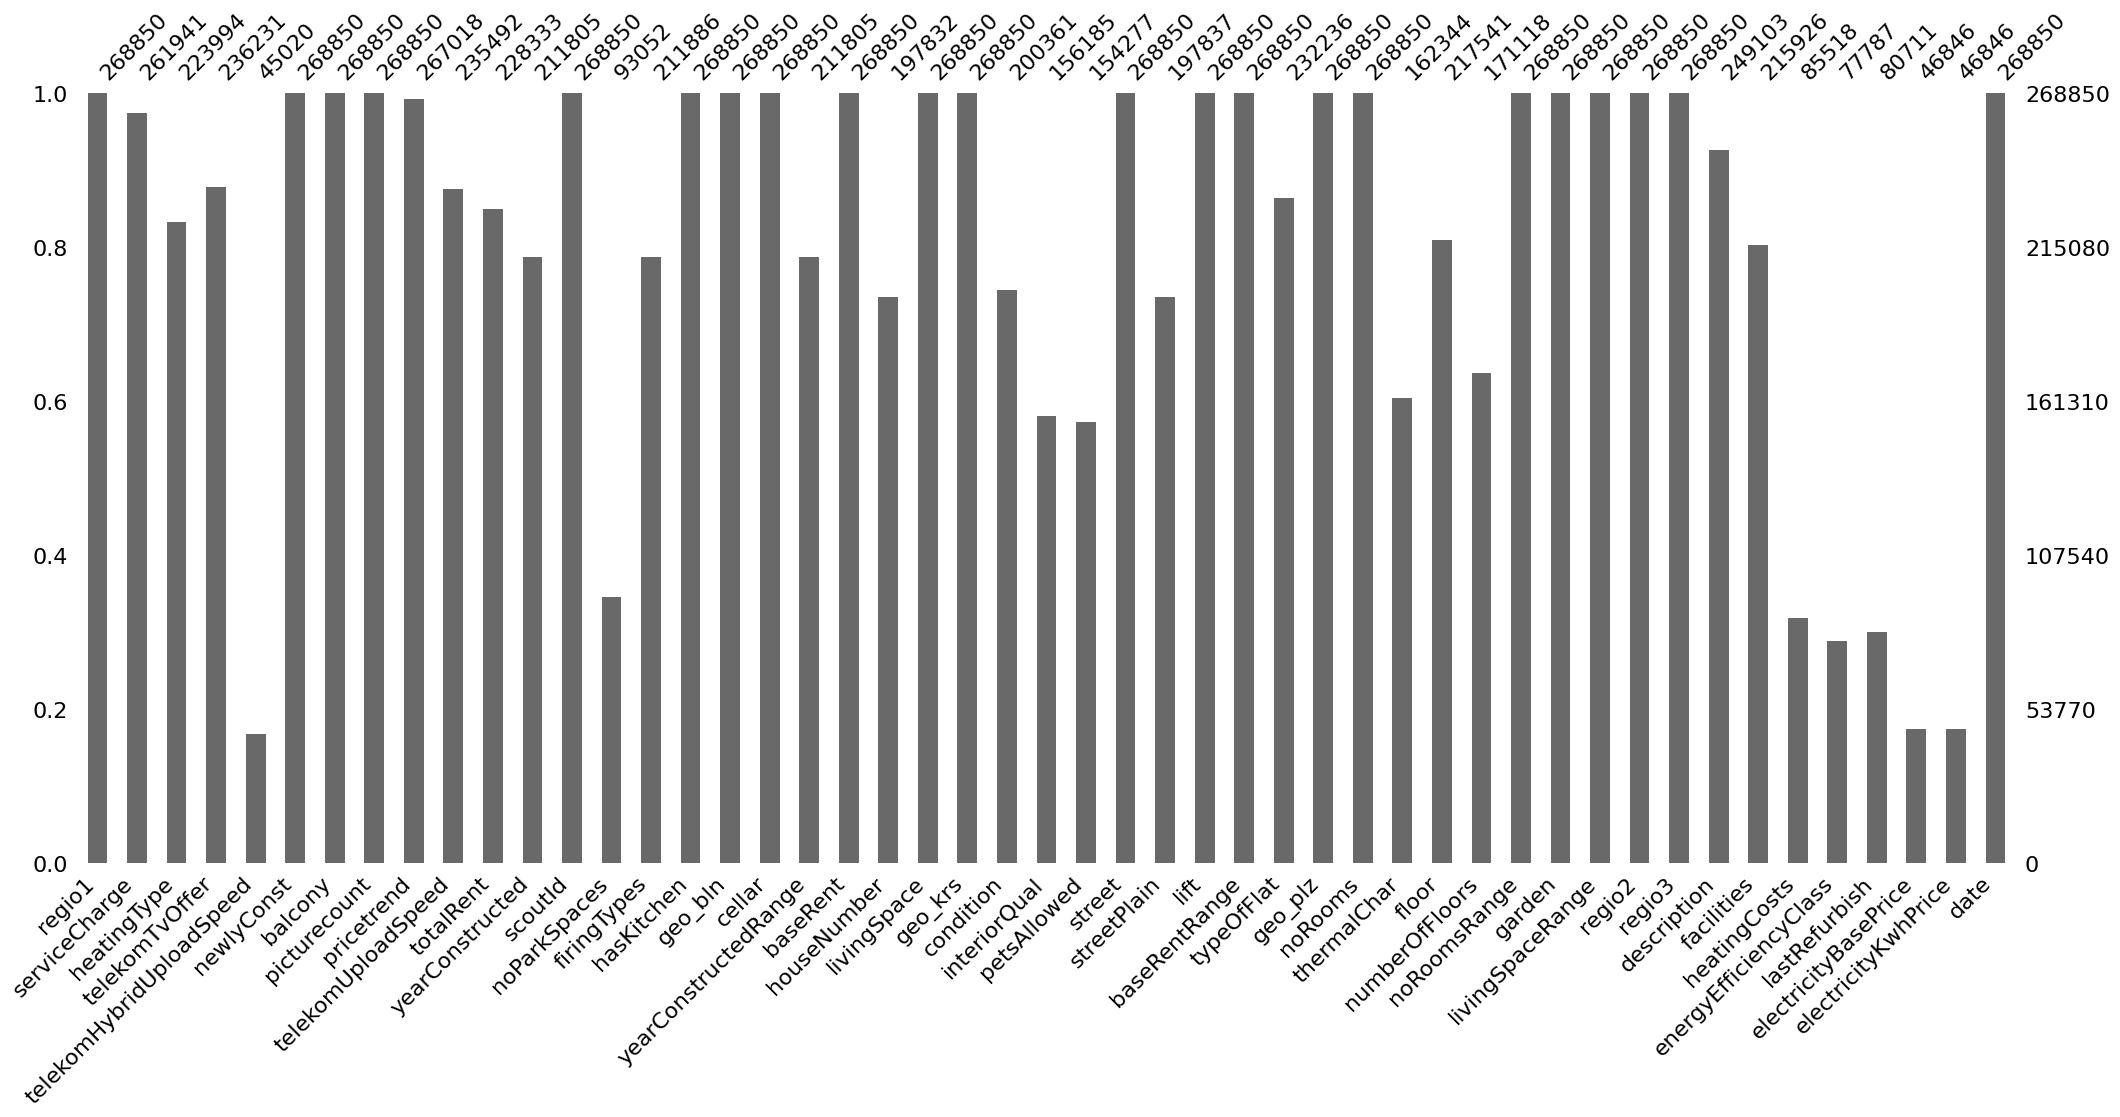

In [5]:
import missingno as msno
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
msno.bar(df)
plt.show()

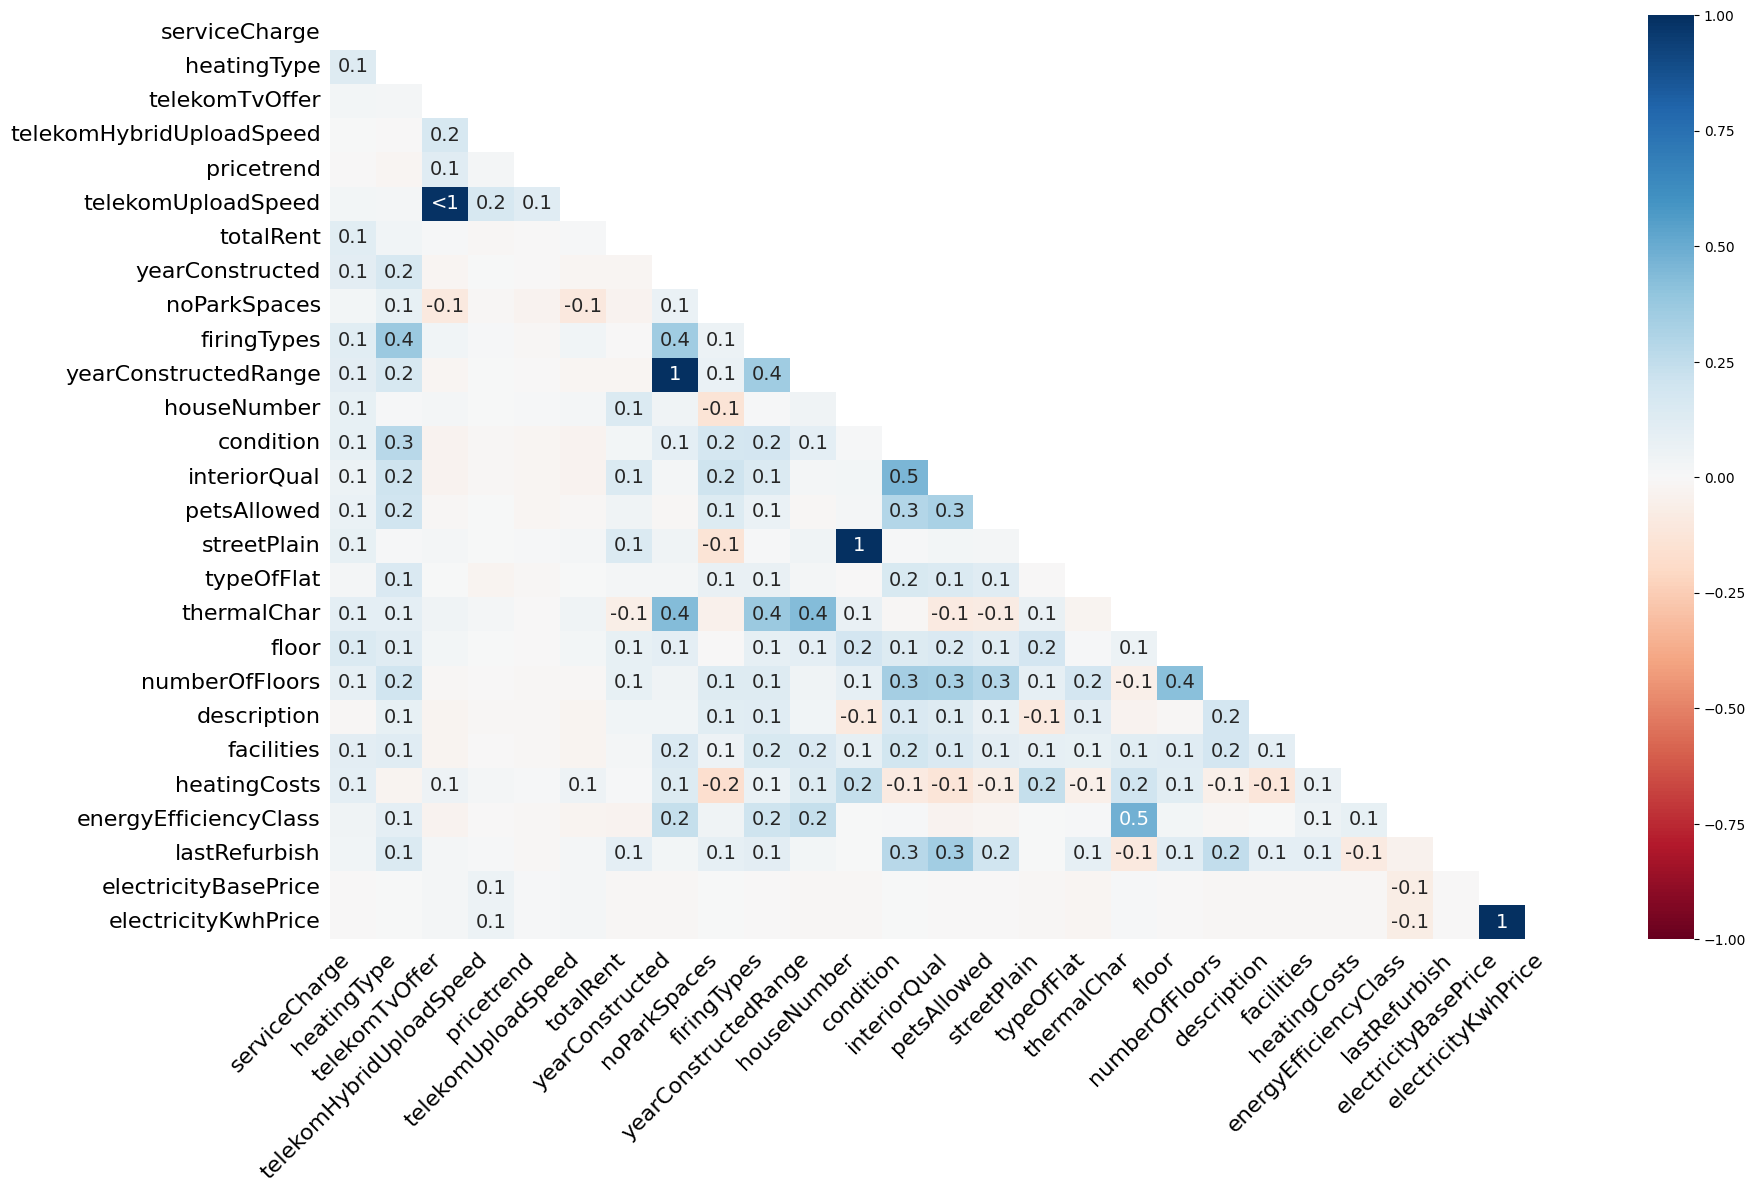

In [6]:
msno.heatmap(df)
plt.show()

## Differ numeric and categorical values 

In [7]:
print(df.info())
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
categorical_cols = df.select_dtypes(include=['object', 'bool'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268850 entries, 0 to 268849
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   regio1                    268850 non-null  object 
 1   serviceCharge             261941 non-null  float64
 2   heatingType               223994 non-null  object 
 3   telekomTvOffer            236231 non-null  object 
 4   telekomHybridUploadSpeed  45020 non-null   float64
 5   newlyConst                268850 non-null  bool   
 6   balcony                   268850 non-null  bool   
 7   picturecount              268850 non-null  int64  
 8   pricetrend                267018 non-null  float64
 9   telekomUploadSpeed        235492 non-null  float64
 10  totalRent                 228333 non-null  float64
 11  yearConstructed           211805 non-null  float64
 12  scoutId                   268850 non-null  int64  
 13  noParkSpaces              93052 non-null   f

In [8]:
print("Numeric columns:")
print(numeric_cols.columns)

print("\nCategorical columns:")
print(categorical_cols.columns)

Numeric columns:
Index(['serviceCharge', 'telekomHybridUploadSpeed', 'picturecount',
       'pricetrend', 'telekomUploadSpeed', 'totalRent', 'yearConstructed',
       'scoutId', 'noParkSpaces', 'yearConstructedRange', 'baseRent',
       'livingSpace', 'baseRentRange', 'geo_plz', 'noRooms', 'thermalChar',
       'floor', 'numberOfFloors', 'noRoomsRange', 'livingSpaceRange',
       'heatingCosts', 'lastRefurbish', 'electricityBasePrice',
       'electricityKwhPrice'],
      dtype='object')

Categorical columns:
Index(['regio1', 'heatingType', 'telekomTvOffer', 'newlyConst', 'balcony',
       'firingTypes', 'hasKitchen', 'geo_bln', 'cellar', 'houseNumber',
       'geo_krs', 'condition', 'interiorQual', 'petsAllowed', 'street',
       'streetPlain', 'lift', 'typeOfFlat', 'garden', 'regio2', 'regio3',
       'description', 'facilities', 'energyEfficiencyClass', 'date'],
      dtype='object')


### Numeric Analysis
Include steps:
- Description
- Visualization (histogram)
- Outlier
- 

In [9]:
df[numeric_cols.columns].describe().T

,count,mean,std,min,25%,50%,75%,max
serviceCharge,261941.00,151.21,308.30,0.00,95.00,135.00,190.00,146118.00
telekomHybridUploadSpeed,45020.00,10.00,0.00,10.00,10.00,10.00,10.00,10.00
picturecount,268850.00,9.79,6.41,0.00,6.00,9.00,13.00,121.00
pricetrend,267018.00,3.39,1.96,-12.33,2.00,3.39,4.57,14.92
telekomUploadSpeed,235492.00,28.80,16.34,1.00,10.00,40.00,40.00,100.00
totalRent,228333.00,901.33,33238.33,0.00,469.80,650.00,985.00,15751535.00
yearConstructed,211805.00,1966.40,46.99,1000.00,1950.00,1973.00,1996.00,2090.00
scoutId,268850.00,106969670.36,12500933.41,28871743.00,106691034.00,111158376.00,113768759.50,115711743.00
noParkSpaces,93052.00,1.33,8.36,0.00,1.00,1.00,1.00,2241.00
yearConstructedRange,211805.00,3.71,2.74,1.00,1.00,3.00,5.00,9.00


array([[<Axes: title={'center': 'serviceCharge'}>,
        <Axes: title={'center': 'telekomHybridUploadSpeed'}>,
        <Axes: title={'center': 'picturecount'}>,
        <Axes: title={'center': 'pricetrend'}>,
        <Axes: title={'center': 'telekomUploadSpeed'}>],
       [<Axes: title={'center': 'totalRent'}>,
        <Axes: title={'center': 'yearConstructed'}>,
        <Axes: title={'center': 'scoutId'}>,
        <Axes: title={'center': 'noParkSpaces'}>,
        <Axes: title={'center': 'yearConstructedRange'}>],
       [<Axes: title={'center': 'baseRent'}>,
        <Axes: title={'center': 'livingSpace'}>,
        <Axes: title={'center': 'baseRentRange'}>,
        <Axes: title={'center': 'geo_plz'}>,
        <Axes: title={'center': 'noRooms'}>],
       [<Axes: title={'center': 'thermalChar'}>,
        <Axes: title={'center': 'floor'}>,
        <Axes: title={'center': 'numberOfFloors'}>,
        <Axes: title={'center': 'noRoomsRange'}>,
        <Axes: title={'center': 'livingSpaceRan

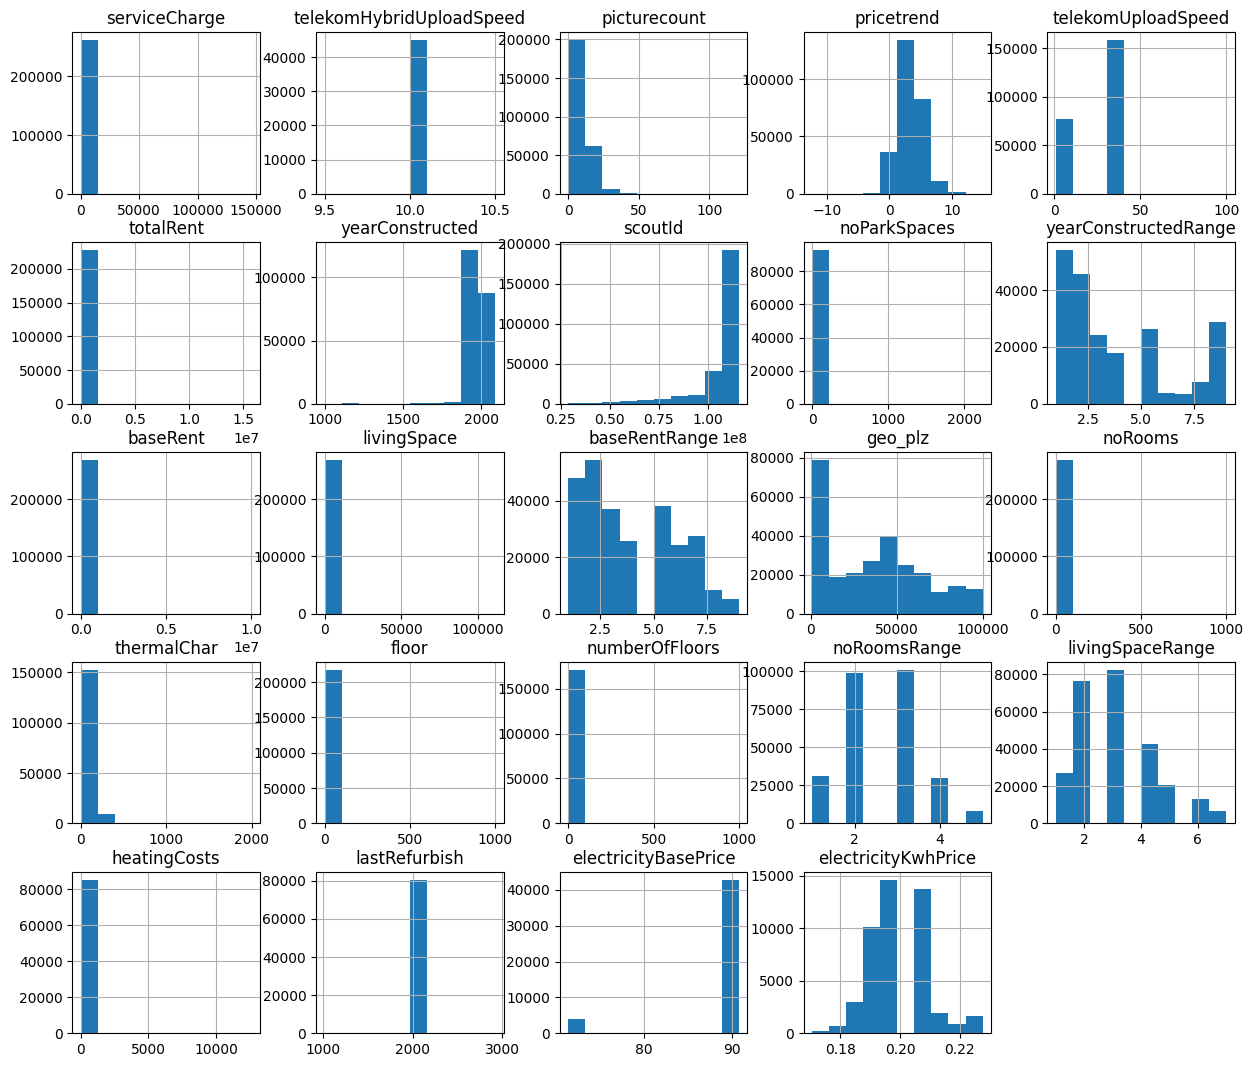

In [10]:
df[numeric_cols.columns].hist(figsize=(15,13))

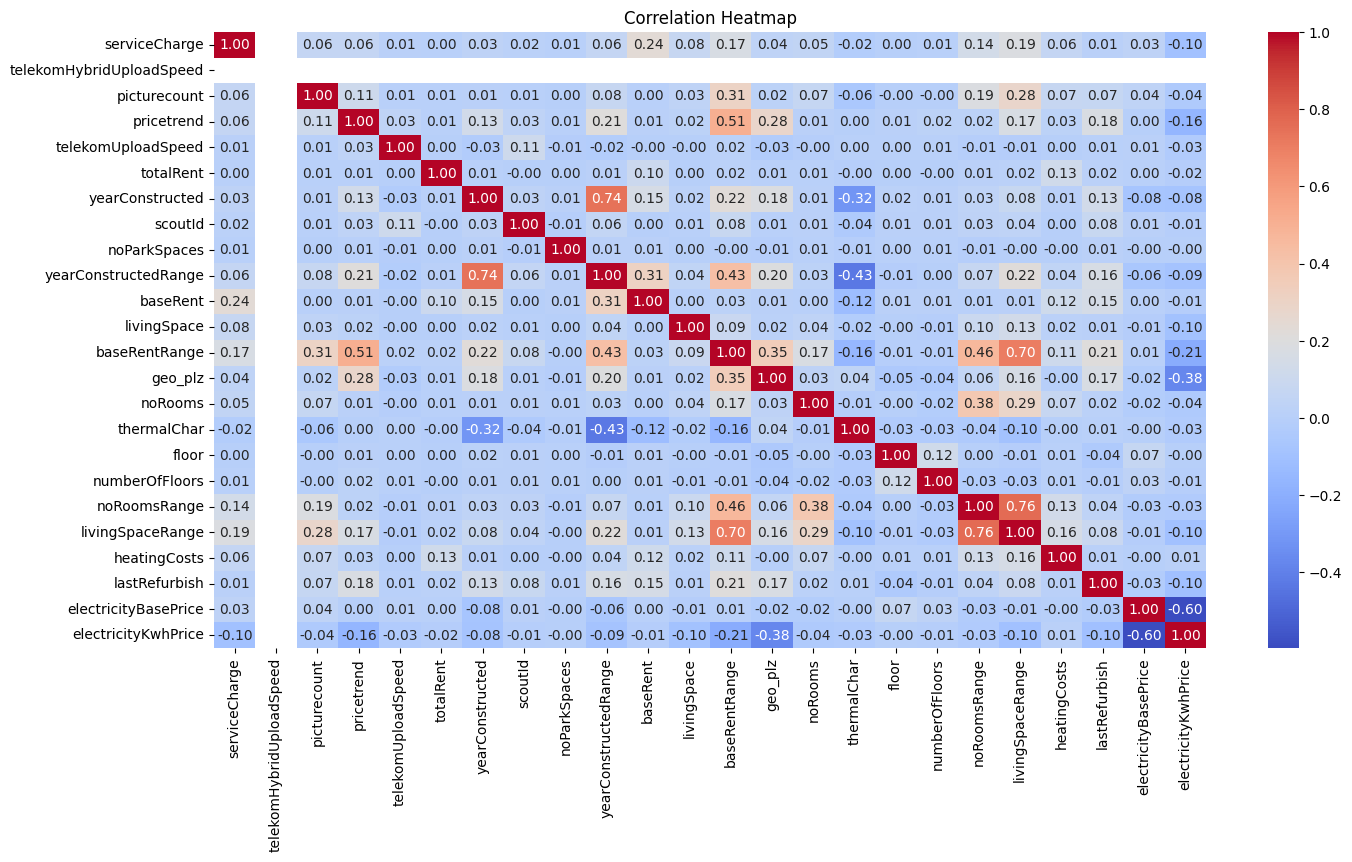

In [11]:
corr = numeric_cols.corr()
plt.figure(figsize=(16, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

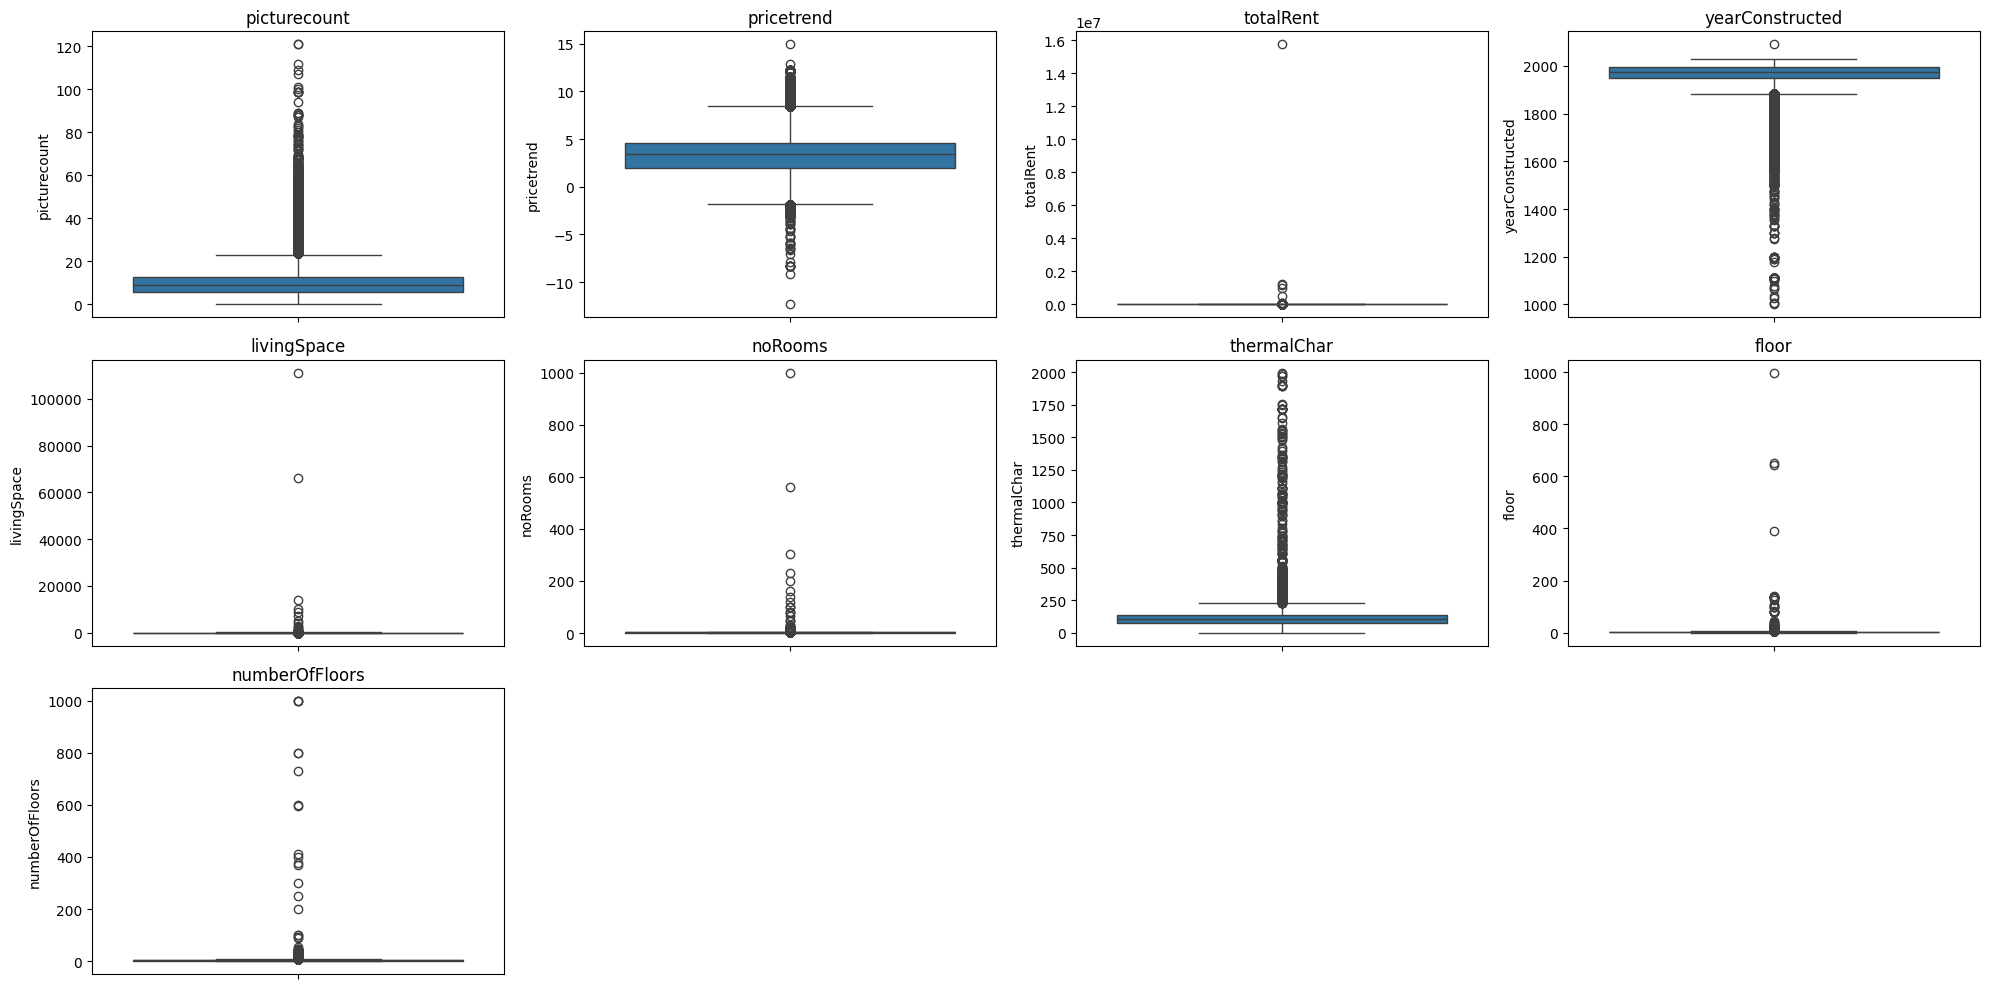

In [12]:
# totalRent, parkSpaces, living Space, noRooms, floor
cols = ['picturecount', 'pricetrend', 'totalRent', 'yearConstructed', 'livingSpace', 'noRooms', 'thermalChar', 'floor', 'numberOfFloors']

plt.figure(figsize=(20,10))

for i, col in enumerate(cols):
    plt.subplot(3, 4, i+1)  
    sns.boxplot(y=df[col])   
    plt.title(col)

plt.tight_layout()
plt.show()

The `thermalChar` feature has a high proportion of missing values, contains significant noise, and shows a very low correlation with the target variable `totalRent` (approximately -0.00). Therefore, this feature will be removed during the preprocessing stage.


In [13]:
df["rent_sum_with_heatingCosts"] = df["baseRent"] + df["serviceCharge"] + df["heatingCosts"]
df["rent_diff_1"] = df["totalRent"] - df["rent_sum_with_heatingCosts"]
df["rent_diff_1"].abs().describe()

count   73023.00
mean       24.89
std       300.64
min         0.00
25%         0.00
50%         0.00
75%        20.00
max     51054.30
Name: rent_diff_1, dtype: float64

In [14]:
df["rent_sum_without_heatingCosts"] = df["baseRent"] + df["serviceCharge"]
df["rent_diff_2"] = df["totalRent"] - df["rent_sum_without_heatingCosts"]
df["rent_diff_2"].abs().describe()

count     224243.00
mean         105.00
std        33367.18
min            0.00
25%            0.00
50%            0.00
75%           46.00
max     15749960.00
Name: rent_diff_2, dtype: float64

In [15]:
print("rent_diff_1 accuracy:", (df["rent_diff_1"].abs() < 1).mean())
print("rent_diff_2 accuracy:", (df["rent_diff_2"].abs() < 1).mean())

rent_diff_1 accuracy: 0.19681606843965035
rent_diff_2 accuracy: 0.5720699274688488


### Analysis of `heatingCosts`

To determine whether `heatingCosts` should be retained, we examined its relationship with the target variable `totalRent`.

In theory, the total rent may be calculated as:

```
totalRent = baseRent + serviceCharge + heatingCosts
```

To verify this assumption, we computed the difference between `totalRent` and the sum of its potential components.

#### Case 1: Including `heatingCosts`

```
rent_sum_with_heatingCosts = baseRent + serviceCharge + heatingCosts
rent_diff_1 = totalRent - rent_sum_with_heatingCosts
```

The descriptive statistics show that although many values have small differences, the overall accuracy (difference < 1) is only **19.7%**.

#### Case 2: Excluding `heatingCosts`

```
rent_sum_without_heatingCosts = baseRent + serviceCharge
rent_diff_2 = totalRent - rent_sum_without_heatingCosts
```

In this case, the accuracy increases significantly to **57.2%**, meaning that `totalRent` is more frequently approximated by `baseRent + serviceCharge` alone.

#### Conclusion

The results suggest that `heatingCosts` is **not consistently included** in the calculation of `totalRent`. Additionally, this feature contains a large proportion of missing values (greater than 40%).

Therefore, keeping `heatingCosts` may introduce noise rather than useful information. For this reason, the feature **will be removed from the dataset during preprocessing**.


### Categorical Analysis
The related variables include:
- Apartment characteristics: 

`typeOfFlat`, `condition`, `heatingType`, `firingTypes`.
- Amenities:

`newlyConst`, `balcony`, `garden`, `cellar`, `lift`, `hasKitchen`. 
- Location:

`regio1`, `regio2`, `regio3`, `geo_bln`, `geo_krs`.

In [16]:
df[categorical_cols.columns].nunique().sort_values(ascending=False)

description              212621
facilities               189526
streetPlain               54490
street                    52373
regio3                     8684
houseNumber                5510
regio2                      419
geo_krs                     419
firingTypes                 132
geo_bln                      16
regio1                       16
heatingType                  13
energyEfficiencyClass        10
condition                    10
typeOfFlat                   10
date                          4
interiorQual                  4
telekomTvOffer                3
petsAllowed                   3
newlyConst                    2
balcony                       2
cellar                        2
hasKitchen                    2
lift                          2
garden                        2
dtype: int64

In [17]:
ap_cols = ['typeOfFlat', 'condition', 'heatingType']
am_cols = ['newlyConst', 'balcony', 'garden', 'cellar', 'lift', 'hasKitchen'] 
loc_cols = ['regio1', 'regio2', 'regio3', 'geo_bln', 'geo_krs']
categorical_cols = ap_cols + am_cols + loc_cols
for col in categorical_cols:
    print("Feature:", col)
    print(df[col].value_counts().head())
    print("Unique:", df[col].nunique())
    print()

Feature: typeOfFlat
typeOfFlat
apartment       131522
roof_storey      34787
ground_floor     31538
other             9519
maisonette        9319
Name: count, dtype: int64
Unique: 10

Feature: condition
condition
well_kept          66591
refurbished        26964
fully_renovated    26368
first_time_use     21959
mint_condition     21938
Name: count, dtype: int64
Unique: 10

Feature: heatingType
heatingType
central_heating                   128977
district_heating                   24808
gas_heating                        19955
self_contained_central_heating     19087
floor_heating                      17697
Name: count, dtype: int64
Unique: 13

Feature: newlyConst
newlyConst
False    247679
True      21171
Name: count, dtype: int64
Unique: 2

Feature: balcony
balcony
True     165734
False    103116
Name: count, dtype: int64
Unique: 2

Feature: garden
garden
False    216093
True      52757
Name: count, dtype: int64
Unique: 2

Feature: cellar
cellar
True     172235
False     96615
Name: c

We will remove the features `geo_bln` (duplicate of `regio1`), `geo_krs` (duplication with `regio2`) and `regio3` (due to having too many unique values) during the preprocessing stage.

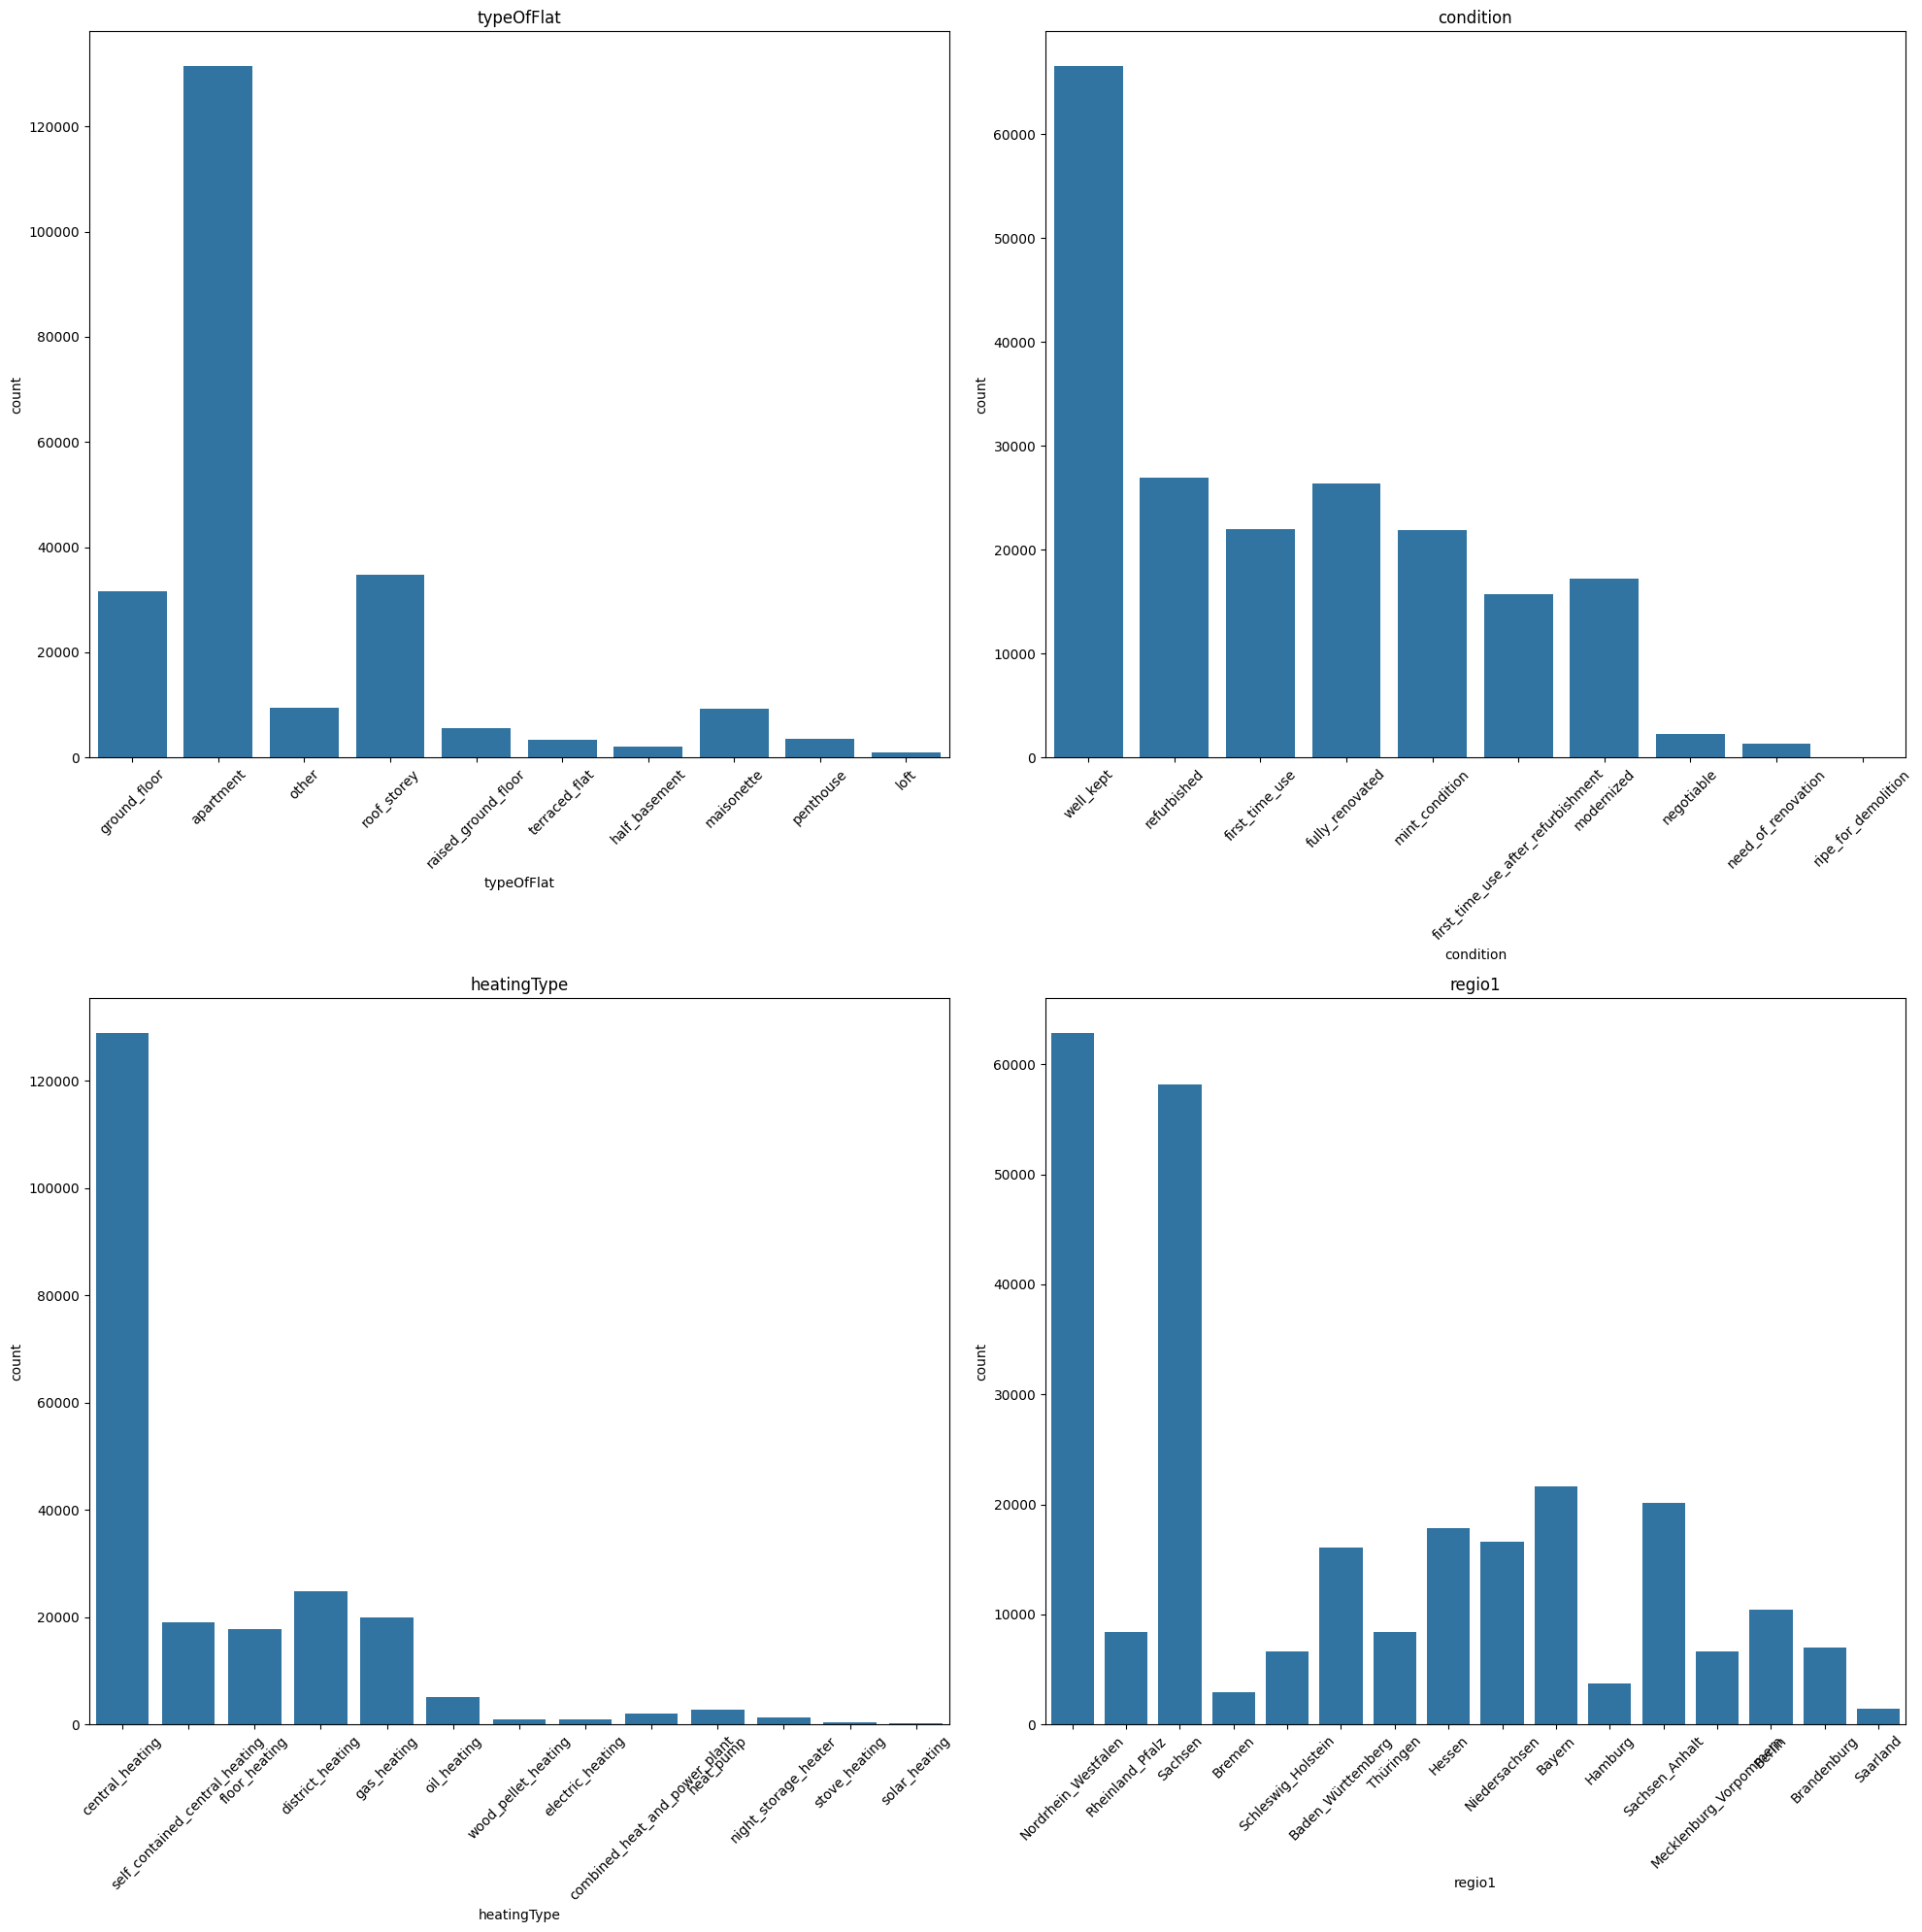

In [18]:
cols = ["typeOfFlat","condition", "heatingType", "regio1"] # Don't plot regio2 because it has too many unique values

fig, axes = plt.subplots(2, 2, figsize=(20,20))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [19]:
for col in cols:
    print(f"------------{col}------------: {df.groupby(col)['totalRent'].mean().sort_values()}")

------------typeOfFlat------------: typeOfFlat
half_basement          673.24
raised_ground_floor    759.46
roof_storey            762.89
ground_floor           780.20
other                  892.15
apartment              967.45
terraced_flat         1166.61
maisonette            1285.54
loft                  1461.40
penthouse             1857.99
Name: totalRent, dtype: float64
------------condition------------: condition
need_of_renovation                    606.86
negotiable                            643.99
refurbished                           689.49
well_kept                             712.38
modernized                            734.44
fully_renovated                       744.30
ripe_for_demolition                   912.62
first_time_use_after_refurbishment    950.83
first_time_use                       1312.10
mint_condition                       2009.37
Name: totalRent, dtype: float64
------------heatingType------------: heatingType
night_storage_heater               566.25
sto

In [20]:
for col in am_cols:
    print(df.groupby(col)["totalRent"].mean())

newlyConst
False    867.17
True    1315.63
Name: totalRent, dtype: float64
balcony
False    649.78
True    1056.56
Name: totalRent, dtype: float64
garden
False   909.29
True    869.94
Name: totalRent, dtype: float64
cellar
False   844.35
True    932.44
Name: totalRent, dtype: float64
lift
False    739.59
True    1419.51
Name: totalRent, dtype: float64
hasKitchen
False    834.89
True    1024.98
Name: totalRent, dtype: float64


# Preprocessing

Based on the results of the EDA pipeline, we selected features that show meaningful statistical relationships with the target variable.

* **Numeric features:** `serviceCharge`, 'telekomHybridUploadSpeed', `picturecount`,
       `pricetrend`, 'telekomUploadSpeed', ```totalRent```, `yearConstructed`,
       'scoutId', 'noParkSpaces', 'yearConstructedRange', `baseRent`,
       `livingSpace`, 'baseRentRange', 'geo_plz', `noRooms`, 'thermalChar',
       `floor`, `numberOfFloors`, 'noRoomsRange', 'livingSpaceRange',
       'heatingCosts', 'lastRefurbish', 'electricityBasePrice',
       'electricityKwhPrice'.
* **Categorical features:** `regio1`, `heatingType`, 'telekomTvOffer', `newlyConst`, `balcony`,
       'firingTypes', `hasKitchen`, 'geo_bln', `cellar`, 'houseNumber',
       'geo_krs', `condition`, 'interiorQual', 'petsAllowed', 'street',
       'streetPlain', `lift`, `typeOfFlat`, `garden`, `regio2`, 'regio3',
       'description', 'facilities', 'energyEfficiencyClass', 'date'.

Other features were removed because they were duplicated, represented range-based variables, or did not demonstrate meaningful statistical relevance during the exploratory analysis.


## Feature Removing

In [21]:
keep_cols = ["serviceCharge", "picturecount", "pricetrend", "totalRent", "yearConstructed",
             "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors", "regio1", "heatingType", "newlyConst",
             "balcony", "hasKitchen", "cellar", "condition", "lift", "typeOfFlat", "garden", "regio2",
]
df = df[keep_cols]

In [22]:
num_cols = [
"serviceCharge", # must float64
"picturecount", # must int64
"pricetrend", # must float64
"totalRent", # must float64
"yearConstructed", # must int64 -> can be float64 because of missing values
"baseRent", # must float64
"livingSpace", # must float64
"noRooms", # must int64 -> can be float64 because of missing values
"floor", # must int64 -> can be float64 because of missing values
"numberOfFloors" # must int64 -> can be float64 because of missing values
]
cat_cols = [
"regio1","heatingType","condition","typeOfFlat","regio2" # must object
]
bool_cols = [
"newlyConst","balcony","hasKitchen","cellar","lift","garden" # must bool
]

## Data Cleaning

### Numeric Features

#### Checking

In [23]:
cols_check_int = ["noRooms","floor","numberOfFloors"]

for col in cols_check_int:
    mask = df[col].notna() & ((df[col] % 1 != 0) | (df[col] < 0) | (df[col] > 1000))
    print(col, df.loc[mask, col].unique()[:10])

mask = df["yearConstructed"].notna() & ((df["yearConstructed"] % 1 != 0) | (df["yearConstructed"] < 1800) | (df["yearConstructed"] > 2024))

print("yearConstructed", df.loc[mask, "yearConstructed"].unique()[:10])

noRooms [ 2.5  1.5  3.5  4.5  5.5  6.5  8.5  2.1  2.2 99.5]
floor [-1.]
numberOfFloors []
yearConstructed [1767. 1780. 1500. 1573. 1685. 1111. 1572. 1534. 1735. 1763.]


In [24]:
df.loc[df["floor"] > df["numberOfFloors"], ["floor","numberOfFloors"]]

,floor,numberOfFloors
34,3.00,2.00
57,3.00,1.00
84,6.00,1.00
351,3.00,2.00
363,3.00,2.00
...,...,...
267586,3.00,2.00
267865,3.00,2.00
267871,1.00,0.00
268674,3.00,0.00


Some observations violate logical constraints where the apartment floor exceeds the total number of floors in the building (`floor` > `numberOfFloors`).
Since these cases represent impossible real-world situations and account for less than 1% of the dataset, they were removed from the dataset to ensure data consistency.

#### Handling

Validate values

In [25]:
df.loc[(df["yearConstructed"] < 1800) | (df["yearConstructed"] > 2025), "yearConstructed"] = np.nan
df.loc[df["noRooms"] <= 0, "noRooms"] = np.nan
df.loc[df["numberOfFloors"] <= 0, "numberOfFloors"] = np.nan
df.loc[df["floor"] < -1, "floor"] = np.nan
mask = (df["floor"] > df["numberOfFloors"]) & df["numberOfFloors"].notna()
df.loc[mask, "floor"] = np.nan

Remove outlier

In [26]:
def remove_outliers_iqr(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df.loc[(df[col] < lower) | (df[col] > upper), col] = np.nan

In [27]:
for col in num_cols:
    remove_outliers_iqr(df, col)

Fill missing values

In [28]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

#### Rechecking


In [29]:
df[num_cols].describe()

,serviceCharge,picturecount,pricetrend,totalRent,yearConstructed,baseRent,livingSpace,noRooms,floor,numberOfFloors
count,268850.00,268850.00,268850.00,268850.00,268850.00,268850.00,268850.00,268850.00,268850.00,268850.00
mean,139.78,9.07,3.30,701.86,1969.97,558.13,69.14,2.56,1.99,3.20
std,63.13,4.93,1.77,311.30,32.75,295.66,23.61,0.85,1.21,1.01
min,0.00,0.00,-1.85,0.00,1881.00,0.00,5.00,1.00,-1.00,1.00
25%,96.00,6.00,2.00,495.00,1959.00,338.00,54.00,2.00,1.00,3.00
50%,130.00,9.00,3.34,622.00,1973.00,469.45,66.00,3.00,2.00,3.00
75%,179.00,12.00,4.48,825.00,1992.00,710.00,82.43,3.00,3.00,4.00
max,332.50,23.00,8.42,1757.53,2022.00,1490.50,136.50,4.50,6.00,7.00


In [30]:
df[num_cols].isna().sum()

serviceCharge      0
picturecount       0
pricetrend         0
totalRent          0
yearConstructed    0
baseRent           0
livingSpace        0
noRooms            0
floor              0
numberOfFloors     0
dtype: int64

### Categorical Features

#### Checking


In [31]:
for col in cat_cols:
    print(col)
    print(df[col].nunique())
    print(df[col].value_counts())
    print()

regio1
16
regio1
Nordrhein_Westfalen       62863
Sachsen                   58154
Bayern                    21609
Sachsen_Anhalt            20124
Hessen                    17845
Niedersachsen             16593
Baden_Württemberg         16091
Berlin                    10406
Thüringen                  8388
Rheinland_Pfalz            8368
Brandenburg                6954
Schleswig_Holstein         6668
Mecklenburg_Vorpommern     6634
Hamburg                    3759
Bremen                     2965
Saarland                   1429
Name: count, dtype: int64

heatingType
13
heatingType
central_heating                   128977
district_heating                   24808
gas_heating                        19955
self_contained_central_heating     19087
floor_heating                      17697
oil_heating                         5042
heat_pump                           2737
combined_heat_and_power_plant       1978
night_storage_heater                1341
wood_pellet_heating                  961
electri

#### Handling

Clean text

In [32]:
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

Replace `NaN` to  `unknown`

In [33]:
for col in cat_cols:
    df[col] = df[col].fillna("unknown")

Frequency encoding

In [34]:
freq = df["regio2"].value_counts(normalize=True)
df["regio2_freq"] = df["regio2"].map(freq)
df = df.drop(columns=["regio2"])

One hot encoding

In [35]:
small_cat = ["regio1","heatingType","condition","typeOfFlat"]

df = pd.get_dummies(df, columns=small_cat, drop_first=True)

#### Rechecking

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268850 entries, 0 to 268849
Data columns (total 65 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   serviceCharge                                 268850 non-null  float64
 1   picturecount                                  268850 non-null  float64
 2   pricetrend                                    268850 non-null  float64
 3   totalRent                                     268850 non-null  float64
 4   yearConstructed                               268850 non-null  float64
 5   baseRent                                      268850 non-null  float64
 6   livingSpace                                   268850 non-null  float64
 7   noRooms                                       268850 non-null  float64
 8   floor                                         268850 non-null  float64
 9   numberOfFloors                                26

### Boolean Features

#### Checking

In [37]:
print(df[bool_cols].dtypes)
df[bool_cols].isna().sum()

newlyConst    bool
balcony       bool
hasKitchen    bool
cellar        bool
lift          bool
garden        bool
dtype: object


newlyConst    0
balcony       0
hasKitchen    0
cellar        0
lift          0
garden        0
dtype: int64

#### Handling

In [38]:
df[bool_cols] = df[bool_cols].astype(int)

#### Rechecking

In [39]:
df[bool_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268850 entries, 0 to 268849
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   newlyConst  268850 non-null  int64
 1   balcony     268850 non-null  int64
 2   hasKitchen  268850 non-null  int64
 3   cellar      268850 non-null  int64
 4   lift        268850 non-null  int64
 5   garden      268850 non-null  int64
dtypes: int64(6)
memory usage: 12.3 MB


## Divide train and test dataset

In [40]:
X = df.drop(columns=["totalRent"])
y = df["totalRent"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,   
    random_state=42
)

#### Merge and save files

In [ ]:
train_df = X_train.copy()
train_df["totalRent"] = y_train

val_df = X_val.copy()
val_df["totalRent"] = y_val

test_df = X_test.copy()
test_df["totalRent"] = y_test

train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

#### Rechecking

In [43]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(172064, 65)
(43016, 65)
(53770, 65)


In [44]:
print(train_df["totalRent"].describe())
print(val_df["totalRent"].describe())
print(test_df["totalRent"].describe())

count   172064.00
mean       701.70
std        310.89
min          0.00
25%        495.00
50%        622.00
75%        825.00
max       1757.53
Name: totalRent, dtype: float64
count   43016.00
mean      700.55
std       310.06
min         0.00
25%       495.00
50%       622.00
75%       820.00
max      1757.00
Name: totalRent, dtype: float64
count   53770.00
mean      703.44
std       313.57
min         0.00
25%       495.00
50%       622.00
75%       830.00
max      1757.00
Name: totalRent, dtype: float64
